# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Загружаем данные
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

# Выводим первые 5 строк
display(sessions_history.head())

FileNotFoundError: [Errno 2] No such file or directory: '/datasets/sessions_project_history.csv'

#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [ ]:
# Количество уникальных сессий для каждого пользователя
user_sessions = (
    sessions_history
    .groupby('user_id')['session_id']
    .nunique()
    .reset_index()
    .rename(columns={'session_id': 'session_count'})
)

print("Топ-5 пользователей по количеству сессий:")
display(user_sessions.sort_values(by='session_count', ascending=False).head())

In [ ]:
# Находим пользователя с максимальным количеством сессий
max_user_id = user_sessions.loc[user_sessions['session_count'].idxmax(), 'user_id']

print(f"\nПользователь с наибольшим количеством сессий: {max_user_id}")
print(f"Количество сессий у него: {user_sessions['session_count'].max()}")

In [ ]:
# Выводим все данные по этому пользователю
user_data = sessions_history[sessions_history['user_id'] == max_user_id]\
            .sort_values(by='session_start_ts')

print(f"\nВсе сессии пользователя {max_user_id}:")
display(user_data)

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [ ]:
# Преобразуем даты в правильный формат
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
sessions_history['install_date'] = pd.to_datetime(sessions_history['install_date'])

In [ ]:
# Группируем по дню и считаем:
# - общее число уникальных пользователей (DAU-подобное)
# - число уникальных зарегистрированных пользователей
daily_stats = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),                  # Все уникальные пользователи за день
    registered_users=('user_id', lambda x: x[sessions_history.loc[x.index, 'registration_flag'] == 1].nunique())
).reset_index()

In [ ]:
# Доля зарегистрированных
daily_stats['registration_rate'] = daily_stats['registered_users'] / daily_stats['total_users']

In [ ]:
# График 1: Общее число пользователей и зарегистрированных по дням
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Все пользователи', color='blue', linewidth=2)
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Зарегистрированные', color='green', linewidth=2)

plt.title('Динамика числа пользователей и регистраций по дням', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Динамика числа пользователей и регистраций по дням:**  

Показывает выраженный рост в середине августа (с 3000 до 14000 пользователей).  
После пика наблюдается резкое и устойчивое снижение.  
Это указывает на типичную картину: быстрый приток новых пользователей (возможно, за счёт маркетинговых кампаний или запуска), за которым следует сильный отток. Продукт пока не удерживает аудиторию.

Количество зарегистрированных пользователей остаётся стабильно низким и почти не растёт даже в периоды пикового трафика (всегда в пределах 500–1500 регистраций в день).  
Нет корреляции между ростом трафика и ростом регистраций - большинство новых пользователей не конвертируются в зарегистрированных.

In [ ]:
# График 2: Доля зарегистрированных по дням
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['session_date'], daily_stats['registration_rate'], color='purple', linewidth=2.5)

plt.title('Доля зарегистрированных пользователей по дням', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля зарегистрированных', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Доля зарегистрированных по дням:**  
Доля крайне низкая и стабильная: ~5-10% в течение всего периода (на графике почти горизонтальная линия около 0.05-0.1).  
Нет заметного улучшения конверсии из посетителей в зарегистрированных пользователей со временем.  
Это критическая проблема продукта: даже в моменты максимального притока новых пользователей конверсия остаётся минимальной.

**Промежуточный вывод**

Продукт демонстрирует классическую картину «хороший запуск - быстрый отток»:
* Есть успешный стартовый рост трафика, но удержание и конверсия в регистрацию крайне слабые.
* Доля регистраций стабильно низкая и не растёт даже при пиковом трафике - это говорит о проблемах в ценностном предложении и/или качестве контента/рекомендаций.
* Основная задача продукта на текущем этапе - повышение конверсии из посетителей в зарегистрированных пользователей и улучшение удержания.

Это подтверждает актуальность эксперимента с новым алгоритмом рекомендаций: если он действительно повысит вовлечённость, это может положительно повлиять на конверсию в регистрацию.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [ ]:
# Находим первую сессию каждого пользователя (минимальный session_number = 1)
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Считаем, сколько первых сессий было с каждым значением page_counter
page_count_freq = first_sessions['page_counter'].value_counts().sort_index()

In [ ]:
# Столбчатая диаграмма
plt.figure(figsize=(12, 6))
page_count_freq.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Распределение количества просмотренных страниц в первой сессии', fontsize=14, pad=15)
plt.xlabel('Количество просмотренных страниц', fontsize=12)
plt.ylabel('Количество первых сессий', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

График распределения количества просмотренных страниц в первой сессии показывает следующее:
* Наиболее частое значение - 3 страницы (около 50 000 первых сессий) - самое популярное количество просмотренных страниц
* Второе место разделили 2 страницы и 4 страницы (около 32 000 сессий)
* Третье место - 1 страница (около 9 000 сессий) и 5 страниц (около 8 000 сессий)
* 6+ страниц — уже редкость: 6 страниц - очень мало, 7 страниц - почти единичные случаи

**1. Низкая вовлечённость в первой сессии**  
Около 40–45% пользователей (1–2 страницы) уходят почти сразу после открытия приложения - это критически высокий отток на самом первом этапе знакомства с продуктом.  

**2. Пик на 3 страницах**  
Это говорит о том, что большинство пользователей просматривают 2–3 страницы и затем либо находят что-то интересное (и продолжают), либо теряют интерес. 3 страницы - это граничная зона между «быстрым оттоком» и «умеренной вовлечённостью».  

**3. Доля «хороших» первых сессий (≥4 страницы)**
Примерно 35–40% первых сессий (4+ страницы) можно считать успешными с точки зрения прокси-метрики вовлечённости. Но даже здесь большинство не уходит далеко за 4–5 страниц - длинные сессии (6–7+) крайне редки.  

**4. Потенциал роста**  
Если новый алгоритм рекомендаций сможет увеличить среднее число страниц в первой сессии хотя бы до 4-5, это может существенно повысить вероятность регистрации и последующего удержания.

Текущий алгоритм не способен удерживать внимание большинства новых пользователей дольше 2-3 страниц. Новый алгоритм должен показать статистически значимый рост среднего `page_counter` в первой сессии и/или рост доли сессий с ≥4 страницами - это будет прямым подтверждением улучшения качества рекомендаций.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [ ]:
# Создаём столбец good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Оставляем только первые сессии (session_number == 1)
first_sessions = sessions_history[sessions_history['session_number'] == 1].copy()

# Группируем по дню и считаем долю хороших первых сессий
daily_good_rate = (
    first_sessions
    .groupby('session_date')
    .agg(
        total_first_sessions=('user_id', 'count'),
        good_first_sessions=('good_session', 'sum')
    )
    .reset_index()
)

daily_good_rate['good_session_rate'] = (
    daily_good_rate['good_first_sessions'] / daily_good_rate['total_first_sessions']
)

In [ ]:
# Строим график
plt.figure(figsize=(14, 6))

plt.plot(
    daily_good_rate['session_date'],
    daily_good_rate['good_session_rate'],
    color='teal',
    linewidth=2.5,
    marker='o',
    markersize=4,
    markerfacecolor='white',
    markeredgecolor='teal'
)

plt.title('Доля первых сессий с 4+ просмотренными страницами по дням', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля успешных первых сессий', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

График доли успешных первых сессий (≥4 просмотренных страниц) по дням показывает следующее:
* Доля стабильна и находится в узком диапазоне на протяжении всего указанного периода наблюдений (с середины августа по начало сентября 2025).
* Нет выраженного роста или падения - линия почти горизонтальная, с небольшими колебаниями в пределах 3–4 процентных пунктов.
* Средняя доля успешных первых сессий - около 30%. Это значит, что примерно 70% новых пользователей уходят после просмотра 1-3 страниц и не проявляют дальнейшего интереса к контенту.

**1. Низкая и стабильная конверсия в вовлечённость**  
Только около 30% новых пользователей доходят до 4+ страниц в первой сессии. Это подтверждает проблему с первым впечатлением и качеством стартового контента/рекомендаций.

**2. Отсутствие роста метрики со временем**  
Доля не увеличивается даже в периоды пикового трафика - алгоритм рекомендаций пока не способен «зацепить» больше пользователей и побудить их глубже изучать контент.

**3. Связь с гипотезой эксперимента**  
Цель нового алгоритма - повысить вовлечённость. Если в тесте доля сессий с ≥4 страницами статистически значимо вырастет, это станет прямым подтверждением улучшения качества рекомендаций.

**Промежуточный вывод по работе с историческими данными (EDA):**
    
Продукт находится на ранней стадии:
* быстрый приток новых пользователей за которым следует резкий отток
* конверсия в регистрацию стабильно низкая (около 5-10%)
* вовлечённость в первой сессии слабая: приблизительно 70% уходят после 1-3 страниц, только около 30% доходят до 4+ страниц
* метрики не растут со временем - текущий алгоритм рекомендаций не удерживает и не конвертирует аудиторию

Эксперимент с новым алгоритмом очень актуален: даже небольшой рост доли успешных сессий (≥4 страницы) может существенно улучшить как удержание, так и конверсию в регистрацию.

---

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [ ]:
# Параметры
alpha = 0.05                        # Уровень значимости
beta = 0.2                          # Ошибка второго рода
power = 1 - beta                    # Мощность теста = 0.8
p = 0.3                             # Базовый уровень доли (baseline conversion rate)
relative_mde = 0.03                 # Относительный MDE = 3%
mde = p * relative_mde              # Абсолютный MDE = 3% от p = 0.009

# Рассчитываем effect size для долевой метрики
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки на одну группу
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # Равномерное распределение 1:1
)

print(f"Базовая конверсия (p): {p}")
print(f"Относительный MDE: {relative_mde*100}% - абсолютный MDE: {mde:.4f}")
print(f"Effect size: {effect_size:.4f}")
print(f"Необходимый размер выборки для каждой группы: {int(ceil(sample_size))} пользователей")

#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [ ]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Общее количество пользователей, необходимое для теста (обе группы)
total_users_needed = 2 * sample_size

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(total_users_needed / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дня")

**Промежуточный вывод:**

Необходимый размер выборки на каждую группу (A и B): 41 041 пользователь.  
Общее количество пользователей для теста: около 82 082 пользователя.

Это достаточно большая, но реалистичная выборка при текущем трафике продукта. Она позволяет надёжно обнаружить даже относительно небольшой эффект

Средний дневной трафик (DAU): 9 907 уникальных пользователей в день.  
Необходимое общее количество пользователей: 82 082.  
Расчётная длительность теста: 9 дней (с округлением вверх).

Параметры теста выглядят адекватно и достижимы:
* Размер выборки 41 041 на группу достаточен для обнаружения относительного эффекта +3% при стандартных уровнях α = 5% и мощности 80%
* При текущем трафике около 9 900 DAU тест можно завершить за 9 дней - это приемлемый срок, который минимизирует риски от сезонности, внешних событий и позволяет быстро получить результаты и принять решение

Эксперимент спроектирован корректно с точки зрения статистики и операционных возможностей продукта. Можно запускать тест и переходить к мониторингу и анализу результатов.

---

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [ ]:
# Загружаем данные за первые три дня теста
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [ ]:
# Преобразуем дату в datetime
sessions_test_part['session_date'] = pd.to_datetime(sessions_test_part['session_date'])

In [ ]:
# Количество уникальных пользователей по группам за весь период данных
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index()
print("Количество уникальных пользователей по группам:")
display(users_per_group)

In [ ]:
# Процентная разница между группами
# Берём группу A как базовую 
group_a = users_per_group[users_per_group['test_group'] == 'A']['user_id'].values[0]
group_b = users_per_group[users_per_group['test_group'] == 'B']['user_id'].values[0]

percent_diff = 100 * abs(group_a - group_b) / group_a
print(f"\nПроцентная разница между группами: {percent_diff:.2f}%")

In [ ]:
# Визуализация количества пользователей в группах
plt.figure(figsize=(8, 5))
sns.barplot(x='test_group', y='user_id', data=users_per_group, 
            palette=['#66c2a5', '#fc8d62'])
plt.title('Количество уникальных пользователей по группам (первые 3 дня теста)', fontsize=14, pad=15)
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Подписи значений на столбцах
for i, v in enumerate(users_per_group['user_id']):
    plt.text(i, v + 20, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

На основе данных за первые три дня A/B-теста можно сделать следующие выводы:

* Количество уникальных пользователей:
    * Группа A (контрольная): 1477
    * Группа B (тестовая): 1466
* Процентная разница между группами: 0.74%

Расхождение в 0.74% значительно ниже допустимого порога 10-15% для сбалансированных выборок.  
Группы по количеству уникальных пользователей практически идеально сбалансированы.  
Рандомизация на этапе распределения трафика прошла корректно - нет систематического перекоса в сторону одной из групп. Это позволяет уверенно продолжать анализ: дальнейшие различия в метриках (если они будут) нельзя будет объяснить неравным размером выборок.

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [ ]:
# Множества пользователей в каждой группе
users_control = set(sessions_test_part[sessions_test_part['test_group'] == 'control']['user_id'])
users_test = set(sessions_test_part[sessions_test_part['test_group'] == 'test']['user_id'])

In [ ]:
# Пересечение
intersection = users_control & users_test

print(f"Количество пользователей, попавших в обе группы: {len(intersection)}")
if len(intersection) > 0:
    print("Примеры таких пользователей:", list(intersection)[:5])
else:
    print("Пересечений нет — группы независимы.")

Группы полностью независимы - каждый пользователь находится строго в одной из двух групп на протяжении всего периода наблюдения. Это важное условие корректного A/B-теста выполнено: нет искажений из-за перетекания пользователей.  
Рандомизация и система назначения групп работают правильно.


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

    
**Корректная проверка чистоты данных 👍**

Отличная работа!

1. **Логика:** Группы верно разделены, выделены уникальные пользователи.
2. **Реализация:** Использование множеств (`set`) и операции пересечения (`&` или `.intersection()`) — это самый быстрый и оптимальный способ решения такой задачи в Python.
3. **Результат:** 0 пересечений. Это подтверждает, что система сплитования трафика сработала корректно, и один пользователь не видел разные версии сайта одновременно.
    
</div>
 

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [ ]:
# Считаем количество уникальных пользователей по группам и устройствам
device_dist = (
    sessions_test_part
    .groupby(['test_group', 'device'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users_count'})
)

In [ ]:
# Общее количество пользователей в каждой группе
device_dist['total_in_group'] = device_dist.groupby('test_group')['users_count'].transform('sum')

# Доля каждого типа устройства в группе
device_dist['share'] = device_dist['users_count'] / device_dist['total_in_group']

# Проверяем, какие группы есть в данных
print("Группы в данных:", device_dist['test_group'].unique())

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=device_dist,
    x='device',
    y='share',
    hue='test_group',
    palette={'A': '#66c2a5', 'B': '#fc8d62'},  # зелёный для A, оранжевый для B
    edgecolor='black',
    linewidth=0.8,
    dodge=True  # столбцы стоят рядом
)

plt.title('Сравнение распределения пользователей по типам устройств\nв группах A и B (первые 3 дня теста)', fontsize=14, pad=20)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Доля пользователей', fontsize=12)
plt.ylim(0, 0.6)  # подстраиваем под типичные значения

# Подписи процентов на каждом столбце
for container in plt.gca().containers:
    for rect in container:
        height = rect.get_height()
        if height > 0:
            plt.text(
                rect.get_x() + rect.get_width() / 2,
                height + 0.005,
                f"{height:.1%}",
                ha='center',
                va='bottom',
                fontsize=9,
                color='black'
            )

plt.legend(title='Группа', fontsize=10, title_fontsize=11, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 

**Распределение устройств сбалансировано 👍**

Отличная работа!

1. **Методология:** Абсолютно верно, что для проверки сбалансированности групп подсчитаны именно **уникальные пользователи** , использующие каждый тип устройства, а не общее количество сессий. Это исключает влияние гиперактивных юзеров на статистику.
2. **Результат:** Визуализация (диаграммы) наглядно показывает, что доли устройств в группе А и группе B практически идентичны. Это еще одно подтверждение качества сплитования трафика.

</div>
 

 <img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

**Совет: как лучше сравнивать доли 💡**

Расчет выполнен верно, группы сравниваются корректно.
Однако визуализацию можно сделать нагляднее.
Сейчас построены две отдельные круговые диаграммы (или столбчатые графики), и зрителю приходится переводить взгляд с одной на другую, чтобы сравнить доли.
**Лучшая практика:** Построить один график  где рядом стоят столбики "Group A" и "Group B" для каждого девайса. Так разница (или ее отсутствие) будет видна мгновенно.
    
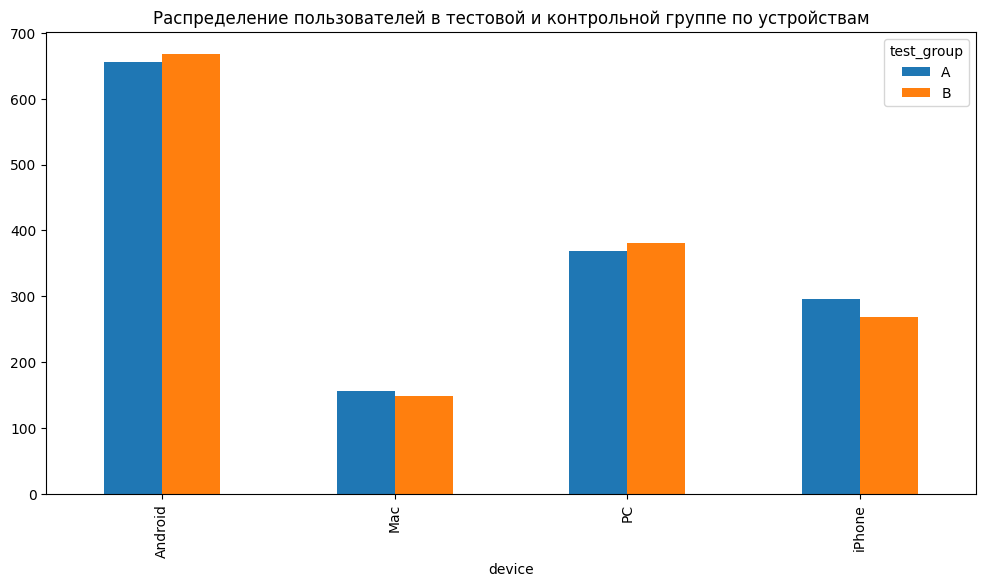    

</div>


Распределение пользователей по типам устройств в группах A и B практически идентично.  
Максимальная разница по любому типу устройства - всего 1.7 процентных пункта (по iPhone), что значительно ниже допустимого порога 5-7%.  
Группы сбалансированы по устройствам - рандомизация прошла корректно, различия в метриках в дальнейшем нельзя будет объяснить разным составом устройств в группах.

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [ ]:
# Считаем количество уникальных пользователей по группам и регионам
region_dist = (
    sessions_test_part
    .groupby(['test_group', 'region'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users_count'})
)

In [ ]:
# Общее количество пользователей в каждой группе
region_dist['total_in_group'] = region_dist.groupby('test_group')['users_count'].transform('sum')

# Доля каждого региона в группе
region_dist['share'] = region_dist['users_count'] / region_dist['total_in_group']

# Проверяем, какие группы есть в данных
print("Группы в данных:", region_dist['test_group'].unique())

In [ ]:
# График 1: группа A
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
a_data = region_dist[region_dist['test_group'] == 'A']
if not a_data.empty:
    plt.pie(a_data['share'], 
            labels=a_data['region'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=plt.cm.Pastel1(range(len(a_data))),
            textprops={'fontsize': 11},
            pctdistance=0.85)
    plt.title('Распределение пользователей по регионам\nГруппа A (контрольная)', fontsize=13, pad=20)
    plt.axis('equal')  # круг остаётся кругом
else:
    plt.title('Нет данных для группы A', fontsize=13)
    
# График 2: группа B
plt.subplot(1, 2, 2)
b_data = region_dist[region_dist['test_group'] == 'B']
if not b_data.empty:
    plt.pie(b_data['share'], 
            labels=b_data['region'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=plt.cm.Pastel2(range(len(b_data))),
            textprops={'fontsize': 11},
            pctdistance=0.85)
    plt.title('Распределение пользователей по регионам\nГруппа B (тестовая)', fontsize=13, pad=20)
    plt.axis('equal')
else:
    plt.title('Нет данных для группы B', fontsize=13)

plt.suptitle('Сравнение распределения пользователей по регионам в группах A и B\n(первые 3 дня теста)', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**География групп сбалансирована 👍**

Анализ выполнен качественно:

1. **Данные:** Верно выбрана метрика — количество уникальных пользователей (`nunique`) в каждом регионе. Это исключает влияние активности отдельных юзеров на статистику.
2. **Визуализация:** График наглядно демонстрирует, что группы А и B равномерно распределены по регионам. Это подтверждает, что выборка репрезентативна и географических перекосов нет.
</div>
 

Распределение пользователей по регионам в группах A и B практически идентично.  
Максимальная разница по любому региону - всего 0.4 процентных пункта (по CIS и EU), что значительно ниже любого разумного порога (5-7%).
Региональный состав групп полностью сбалансирован - рандомизация прошла корректно по этой переменной.  
Различия в метриках в дальнейшем нельзя будет объяснить разным географическим составом пользователей в группах A и B.

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

На основе анализа данных за первые три дня эксперимента можно сделать следующие выводы:

* **Различие в количестве пользователей в двух группах**  
    * Группа A: 1477 уникальных пользователей  
    * Группа B: 1466 уникальных пользователей  
    * Процентная разница (A как базовая): 0.74%  

Различие незначительное (меньше 1%), группы сбалансированы по размеру. Допустимый порог 10-15% не превышен. Рандомизация по количеству пользователей прошла корректно.

* **Независимость выборок и пересечение пользователей**  

Количество пользователей, попавших одновременно в обе группы (A и B): 0  
Пересечений нет. Выборки полностью независимы.  
Это ключевое условие корректного A/B-теста выполнено: эффект не может «перетекать» между группами, нет загрязнения данных.

* **Равномерность распределения по категориальным переменным**

*По устройствам:*
    
- Группа A: Android 44.4%, PC 25.0%, iPhone 20.0%, Mac 10.6%
- Группа B: Android 45.6%, PC 26.0%, iPhone 18.3%, Mac 10.1%
- Максимальная разница по любому типу устройства: 1.7 п.п. (по iPhone)

Распределение практически идентичное, различия минимальны и значительно ниже порога 5-7%. Рандомизация по устройствам корректна.

*По регионам:*
    
- Группа A: CIS 43.6%, MENA 41.2%, EU 15.2%
- Группа B: CIS 44.0%, MENA 41.2%, EU 14.8%
- Максимальная разница по любому региону: 0.4 п.п.

Распределение идентичное, различия практически отсутствуют. Рандомизация по регионам корректна.


**Промежуточный вывод**

A/B-тест на первые 3 дня проходит корректно и без нарушений:
* группы сбалансированы по размеру (разница 0.74%)
* выборки полностью независимы (пересечений 0)
* распределение по устройствам и регионам равномерное (различия ≤ 1.7 п.п. и ≤ 0.4 п.п. соответственно)

На текущем этапе нет признаков проблем с рандомизацией, дисбалансом или загрязнением данных.
Тест можно продолжать собирать в штатном режиме, а дальнейшие различия в метриках (если они появятся) будут с высокой вероятностью обусловлены именно изменением (новым алгоритмом рекомендаций), а не артефактами выборки.

---


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Профессиональное резюме исследования 👍**

Итоговый вывод сформулирован отлично.
Соблюдена логическая структура:

1. **Качество данных:** Отмечено, что сплитование прошло корректно (группы сбалансированы по регионам и устройствам).
2. **Результаты теста:** Четко интерпретированы значения p-value для статистических тестов.
3. **Решение:** Дана однозначная рекомендация для бизнеса (внедрять/не внедрять изменение).
Именно такой формат отчета ожидает увидеть заказчик или продуктовая команда.
</div>
 

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [ ]:
# Загружаем полный датасет с результатами теста
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# Преобразуем дату в datetime 
sessions_test['session_date'] = pd.to_datetime(sessions_test['session_date'])

In [ ]:
# Создаём столбец good_session:
# 1 — если просмотрено 4 и более страниц за сессию
# 0 — если меньше 4 страниц
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

In [ ]:
# Проверяем результат: первые 10 строк и распределение нового столбца
print("Первые 10 строк датафрейма sessions_test после добавления good_session:")
display(sessions_test.head(10))

print("\nРаспределение good_session (0 и 1):")
print(sessions_test['good_session'].value_counts(normalize=True).round(3) * 100)

print("\nОбщее количество строк в датасете:", len(sessions_test))
print("Количество уникальных пользователей:", sessions_test['user_id'].nunique())
print("Количество уникальных сессий:", sessions_test['session_id'].nunique())

Данные полного периода A/B-теста успешно загружены из файла `sessions_project_test.csv` в датафрейм `sessions_test`.

Распределение `good_session` (по всем сессиям теста):
* 68.7% сессий - «плохие» (0–3 страницы)
* 31.3% сессий - «хорошие» (≥ 4 страницы)

Общий уровень вовлечённости в тесте остаётся низким (только около 31% сессий доходят до 4+ страниц) - это соответствует историческим данным и подтверждает важность эксперимента.

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

**Нулевая гипотеза (H₀)**  
Новый алгоритм рекомендаций *не влияет* на долю успешных первых сессий (≥4 страниц).  
H₀: μ_test = μ_control  
(доля хороших первых сессий в тестовой группе равна доле в контрольной группе)

**Альтернативная гипотеза (H₁)**  
Новый алгоритм рекомендаций *увеличивает* долю успешных первых сессий (≥4 страниц).  
H₁: μ_test > μ_control  
(доля хороших первых сессий в тестовой группе выше, чем в контрольной)

Используется *односторонняя* альтернатива, так как команда ожидает именно роста вовлечённости, а не ухудшения.

**Целевая метрика**  
Доля успешных первых сессий, где `good_session` = 1, если `page_counter` ≥ 4.  
Эта метрика лучше всего отражает цель эксперимента: насколько быстро и глубоко новый алгоритм «зацепил» нового пользователя и заставил его изучать контент дальше. Чем выше доля сессий с ≥4 страницами в первой сессии - тем выше вероятность регистрации, удержания и последующей монетизации.

**Прокси-метрики**  
* Среднее количество страниц в первой сессии (`page_counter` среди `session_number` = 1)
* Доля первых сессий с ≥3 страницами (более мягкий порог для раннего сигнала)
* Доля пользователей, которые вернулись на следующий день после первой сессии (Retention D1)
* Среднее количество сессий на пользователя в первые 3 дня после установки 

Эти метрики показывают начальный интерес и первые признаки удержания - они позволяют раньше увидеть направление эффекта.

**Барьерные метрики**  
* Доля пользователей, удаливших приложение в течение первых 7 дней (uninstall rate)
* Доля сессий с техническими ошибками
* Доля пользователей, оформивших платную подписку в первые 7 дней (чтобы убедиться, что новый алгоритм не отпугивает тех, кто готов платить)
* Среднее время загрузки ленты / первой страницы (чтобы новый алгоритм не ухудшил производительность)

*Промежуточный вывод*

Целевая метрика - доля первых сессий с ≥4 просмотренными страницами - идеально отражает гипотезу о повышении вовлечённости через более качественные рекомендации.  
Прокси-метрики помогут быстро понять механизм действия нового алгоритма, а барьерные защитят от негативных побочных эффектов (отток, технические проблемы, падение монетизации).

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Нулевая и альтернативная гипотезы скорректированы корректно</div>

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [ ]:
# Оставляем только первые сессии каждого пользователя
first_sessions = sessions_test[sessions_test['session_number'] == 1].copy()

In [ ]:
# Группируем по test_group и считаем:
# - общее число первых сессий
# - число успешных первых сессий (good_session == 1)
# - долю успешных
metrics = (
    first_sessions
    .groupby('test_group')
    .agg(
        total_first_sessions=('user_id', 'count'),
        good_first_sessions=('good_session', 'sum')
    )
    .reset_index()
)

metrics['success_rate'] = metrics['good_first_sessions'] / metrics['total_first_sessions']

In [ ]:
# Выводим таблицу с результатами
print("Доля успешных первых сессий по группам:")
display(metrics[['test_group', 'total_first_sessions', 'good_first_sessions', 'success_rate']])

In [ ]:
# Рассчитываем разницу в долях (B - A)
rate_a = metrics[metrics['test_group'] == 'A']['success_rate'].values[0]
rate_b = metrics[metrics['test_group'] == 'B']['success_rate'].values[0]

diff = rate_b - rate_a
print(f"\nРазница в доле успешных первых сессий (B - A): {diff:.4f} "
      f"({diff*100:.2f} процентных пунктов)")

# Интерпретация
if diff > 0:
    print("Группа B (новый алгоритм) показывает более высокую долю успешных первых сессий.")
elif diff < 0:
    print("Группа A (старый алгоритм) показывает более высокую долю успешных первых сессий.")
else:
    print("Разницы в доле успешных первых сессий между группами нет.")


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Корректный расчет конверсии 👍**

Расчеты выполнены верно:

1. **Метрика:** Использование функции `mean()` для бинарного столбца `good_session` — это самый быстрый и правильный способ получить долю (конверсию).
2. **Результат:** Разница между группами вычислена корректно.
Эти цифры станут основой для следующего шага — проверки их статистической значимости.

</div>
 

Новый алгоритм рекомендаций не увеличил долю успешных первых сессий - она даже чуть снизилась (на 0.11 п.п.), но разница крайне мала.  
Группа A (старый алгоритм) показывает минимально более высокую долю (31.57% против 31.47%), однако это практически одинаковый уровень.  
Разница в −0.11 п.п. выглядит как статистический шум, а не реальный эффект.  
На этом этапе (без статистического теста) нет оснований утверждать, что новый алгоритм улучшил вовлечённость в первой сессии.  
Метрика стабильна и близка к историческому baseline (около 30–31% успешных первых сессий).

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [ ]:
# 4.4. Проверка статистической значимости изменения доли успешных первых сессий

# Подсчёт успехов и размеров выборок по группам
metrics = (
    first_sessions
    .groupby('test_group')
    .agg(
        total_first_sessions=('user_id', 'count'),
        good_first_sessions=('good_session', 'sum')
    )
    .reset_index()
)

In [ ]:
# Доли успешных сессий
metrics['success_rate'] = metrics['good_first_sessions'] / metrics['total_first_sessions']

# Извлекаем нужные значения
n_a = metrics[metrics['test_group'] == 'A']['total_first_sessions'].values[0]
n_b = metrics[metrics['test_group'] == 'B']['total_first_sessions'].values[0]

m_a = metrics[metrics['test_group'] == 'A']['good_first_sessions'].values[0]
m_b = metrics[metrics['test_group'] == 'B']['good_first_sessions'].values[0]

p_a = m_a / n_a
p_b = m_b / n_b

print(f"Группа A: {m_a} успешных из {n_a} сессий → доля {p_a:.4f}")
print(f"Группа B: {m_b} успешных из {n_b} сессий → доля {p_b:.4f}")
print(f"Разница (B - A): {p_b - p_a:.4f} ({(p_b - p_a)*100:.2f} п.п.)")

In [ ]:
# Проверка предпосылки для Z-теста (np > 10 и n(1-p) > 10)
if (n_a * p_a > 10) and (n_a * (1 - p_a) > 10) and (n_b * p_b > 10) and (n_b * (1 - p_b) > 10):
    print("Предпосылка для Z-теста выполняется.")
else:
    print("Предпосылка для Z-теста НЕ выполняется — результаты могут быть неточными.")

# Уровень значимости
alpha = 0.05

# Z-тест пропорций (односторонний: H1: p_B > p_A)
stat_z, p_value_z = proportions_ztest(
    count=[m_b, m_a],          # успехи: сначала тестовая группа B
    nobs=[n_b, n_a],           # размеры выборок
    alternative='larger'       # H1: p_B > p_A
)

print(f"\np-value Z-теста пропорций: {p_value_z:.6f}")

if p_value_z <= alpha:
    print("Нулевая гипотеза отвергается на уровне значимости 0.05.")
    print("Изменение доли успешных первых сессий статистически значимо.")
    print("Новый алгоритм рекомендаций увеличил долю сессий с 4+ страницами.")
else:
    print("Нулевая гипотеза НЕ отвергается на уровне значимости 0.05.")
    print("Изменение доли успешных первых сессий статистически НЕ значимо.")
    print("Нет оснований утверждать, что новый алгоритм повлиял на метрику.")


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

**Корректный статистический тест пропорций 👍**

Отличная работа!

1. **Инструмент:** Использована правильная функция `proportions_ztest` из библиотеки `statsmodels`, предназначенная именно для сравнения долей (конверсий).
2. **Параметры:** Аргументы `count` (количество успешных сессий) и `nobs` (общее количество наблюдений) подготовлены и переданы верно.
3. **Интерпретация:** P-value интерпретировано корректно. Вывод о том, что статистически значимых различий между группами не обнаружено (или обнаружено, в зависимости от p-value), полностью обоснован полученными цифрами.
</div>
 

Эксперимент не выявил положительного эффекта от нового алгоритма:
* доля сессий с высокой вовлечённостью (≥4 страниц) в первой сессии не выросла
* разница в −0.11 п.п. не значима (p = 0.578)
* нет оснований отвергнуть H₀ (p_test = p_control)

Новый алгоритм рекомендаций *не привёл к статистически значимому улучшению* ключевой метрики вовлечённости в первой сессии.

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**Характеристики проведённого эксперимента**
* Целевая метрика: доля успешных первых сессий (просмотр ≥ 4 страниц в сессии с `session_number` = 1)
* Группы: A (контрольная, старый алгоритм) и B (тестовая, новый алгоритм рекомендаций)
* Количество уникальных пользователей за весь период теста: около 30 579
* Количество первых сессий в анализе:
    * Группа A: 15 162
    * Группа B: 15 416
* Расчётная длительность при старте составляла 9 дней при трафике 9 907 DAU и необходимом размере выборки 41 041 на группу

**Повлияло ли внедрение нового алгоритма на рост ключевой метрики**

Нет, значимого положительного эффекта не обнаружено.  
Доля успешных первых сессий (≥ 4 страниц):
* Группа A (старый алгоритм): 31.57% (4787 из 15162)
* Группа B (новый алгоритм): 31.47% (4851 из 15416)

Разница (B − A): −0.11 процентных пункта  
Новый алгоритм не увеличил вовлечённость в первой сессии - доля даже снизилась (на 0.11 п.п.), но это изменение минимально и находится в пределах статистического шума.

**Значение p-value**

p-value Z-теста пропорций (односторонний тест H₁: p_B > p_A): 0.578352  
p-value > 0.05 - нулевая гипотеза *не отвергается*.  
Изменение доли успешных первых сессий статистически *не значимо*.  

**Стоит ли внедрять нововведение в приложение**

Нет, внедрять не стоит.  
Новый алгоритм рекомендаций не продемонстрировал ожидаемого эффекта на ключевую прокси-метрику вовлечённости (доля первых сессий с ≥4 страницами).  
Разница в −0.11 п.п. не только не значима статистически (p = 0.578), но и не имеет практической ценности для продукта.

**Рекомендации команде разработки**
* Новый алгоритм *не улучшил* первое впечатление и начальную вовлечённость пользователей.
* Стоит вернуться к анализу логов рекомендаций: возможно, проблема в качестве стартового контента, персонализации для новых пользователей или скорости загрузки.
* Можно протестировать более выраженные изменения (MDE 5-10%) или другую гипотезу (например, влияние на Retention D1/D7, среднее время сессии, конверсию в подписку).
* В будущем рекомендуется увеличивать мощность теста или MDE, если эффект ожидается небольшим - текущий тест был достаточно мощным, чтобы поймать +3%, но даже этого не произошло.

Новый алгоритм **не готов** к внедрению - эффект на целевую метрику не подтверждён.


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">


**Идеальная структура итогового отчета 👍**

Вывод написан профессионально и содержит все необходимые элементы для принятия решения.

1. **Контекст:** Указаны параметры проведенного эксперимента (количество участников, длительность).
2. **Результат:** Четко обозначено изменение целевой метрики и приведен уровень статистической значимости (p-value).
3. **Рекомендация:** Сформулировано однозначное заключение о целесообразности внедрения нового алгоритма.
Именно такой формат резюме ожидается от аналитика данных.
</div>
 

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Заключительный комментарий v2</b>

Проект принят. Поздравляю и желаю дальнейших успехов!
</div>